### 1. Data Loading

In [1]:
# =============================================================================
# Optimized ResNet50 Pipeline - Original Dataset Only
# =============================================================================

import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

print("Modules loaded")

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Modules loaded


In [2]:
# =============================================================================
# Step 1: Load Original Dataset
# =============================================================================
data_dir = '/kaggle/input/nct-crc-he-100k/NCT-CRC-HE-100K'
filepaths = []
labels = []

for fold in os.listdir(data_dir):
    if fold == 'BACK':
        continue
    foldpath = os.path.join(data_dir, fold)
    for file in os.listdir(foldpath):
        filepaths.append(os.path.join(foldpath, file))
        labels.append(fold)

df = pd.DataFrame({'filepaths': filepaths, 'labels': labels})

print("Number of classes:", df['labels'].nunique())
print("Samples per class:\n", df['labels'].value_counts())


Number of classes: 8
Samples per class:
 labels
TUM     14317
MUS     13536
LYM     11557
DEB     11512
STR     10446
ADI     10407
MUC      8896
NORM     8763
Name: count, dtype: int64


In [3]:
# =============================================================================
# Step 2: Split Dataset
# =============================================================================
train_df, temp_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=123,
                                     stratify=df['labels'])
valid_df, test_df = train_test_split(temp_df, train_size=0.5, shuffle=True, random_state=123,
                                     stratify=temp_df['labels'])


In [4]:
# =============================================================================
# Step 3: Data Generators
# =============================================================================
img_size = (128, 128)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
batch_size = 128

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
valid_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_gen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels',
                                                target_size=img_size, class_mode='categorical',
                                                color_mode='rgb', shuffle=True, batch_size=batch_size)
valid_generator = valid_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels',
                                                target_size=img_size, class_mode='categorical',
                                                color_mode='rgb', shuffle=True, batch_size=batch_size)
test_generator = test_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels',
                                              target_size=img_size, class_mode='categorical',
                                              color_mode='rgb', shuffle=False, batch_size=batch_size)

Found 71547 validated image filenames belonging to 8 classes.
Found 8943 validated image filenames belonging to 8 classes.
Found 8944 validated image filenames belonging to 8 classes.


In [5]:

# =============================================================================
# Step 4: Build ResNet50 Model
# =============================================================================
base_model = ResNet50(include_top=False, weights="imagenet", input_shape=img_shape, pooling='max')
base_model.trainable = False  # Freeze base initially

model = models.Sequential([
    base_model,
    layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    layers.Dense(
        256,
    ),
    layers.Dropout(rate=0.45, seed=123),
    layers.Dense(len(train_generator.class_indices), activation='softmax')
])


94765736/94765736 [==============================] - 5s 0us/step


In [6]:

# =============================================================================
# Step 5: Compile and Train Head Only
# =============================================================================
model.compile(optimizer=Adamax(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_head = model.fit(train_generator, epochs=5, validation_data=valid_generator, shuffle=False)

Epoch 1/5
559/559 [==============================] - 564s 999ms/step - loss: 0.3878 - accuracy: 0.8907 - val_loss: 0.2160 - val_accuracy: 0.9329
Epoch 2/5
559/559 [==============================] - 152s 272ms/step - loss: 0.2280 - accuracy: 0.9291 - val_loss: 0.1794 - val_accuracy: 0.9432
Epoch 3/5
559/559 [==============================] - 140s 250ms/step - loss: 0.1847 - accuracy: 0.9403 - val_loss: 0.1682 - val_accuracy: 0.9467
Epoch 4/5
559/559 [==============================] - 141s 252ms/step - loss: 0.1657 - accuracy: 0.9455 - val_loss: 0.1610 - val_accuracy: 0.9468
Epoch 5/5
559/559 [==============================] - 135s 242ms/step - loss: 0.1509 - accuracy: 0.9483 - val_loss: 0.1573 - val_accuracy: 0.9502


In [7]:
# =============================================================================
# Step 6: Fine-Tune Last Layers of ResNet
# =============================================================================
base_model.trainable = True
for layer in base_model.layers[:-20]:  # Freeze first layers, fine-tune last 20
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(train_generator, epochs=10, validation_data=valid_generator, shuffle=False)


Epoch 1/10
559/559 [==============================] - 146s 247ms/step - loss: 0.1812 - accuracy: 0.9401 - val_loss: 0.1631 - val_accuracy: 0.9480
Epoch 2/10
559/559 [==============================] - 146s 260ms/step - loss: 0.1127 - accuracy: 0.9611 - val_loss: 0.1532 - val_accuracy: 0.9530
Epoch 3/10
559/559 [==============================] - 136s 243ms/step - loss: 0.0786 - accuracy: 0.9732 - val_loss: 0.1484 - val_accuracy: 0.9552
Epoch 4/10
559/559 [==============================] - 145s 260ms/step - loss: 0.0553 - accuracy: 0.9820 - val_loss: 0.1469 - val_accuracy: 0.9544
Epoch 5/10
559/559 [==============================] - 134s 239ms/step - loss: 0.0397 - accuracy: 0.9879 - val_loss: 0.1469 - val_accuracy: 0.9573
Epoch 6/10
559/559 [==============================] - 153s 273ms/step - loss: 0.0284 - accuracy: 0.9921 - val_loss: 0.1471 - val_accuracy: 0.9574
Epoch 7/10
559/559 [==============================] - 137s 245ms/step - loss: 0.0209 - accuracy: 0.9949 - val_loss: 0.1485 -

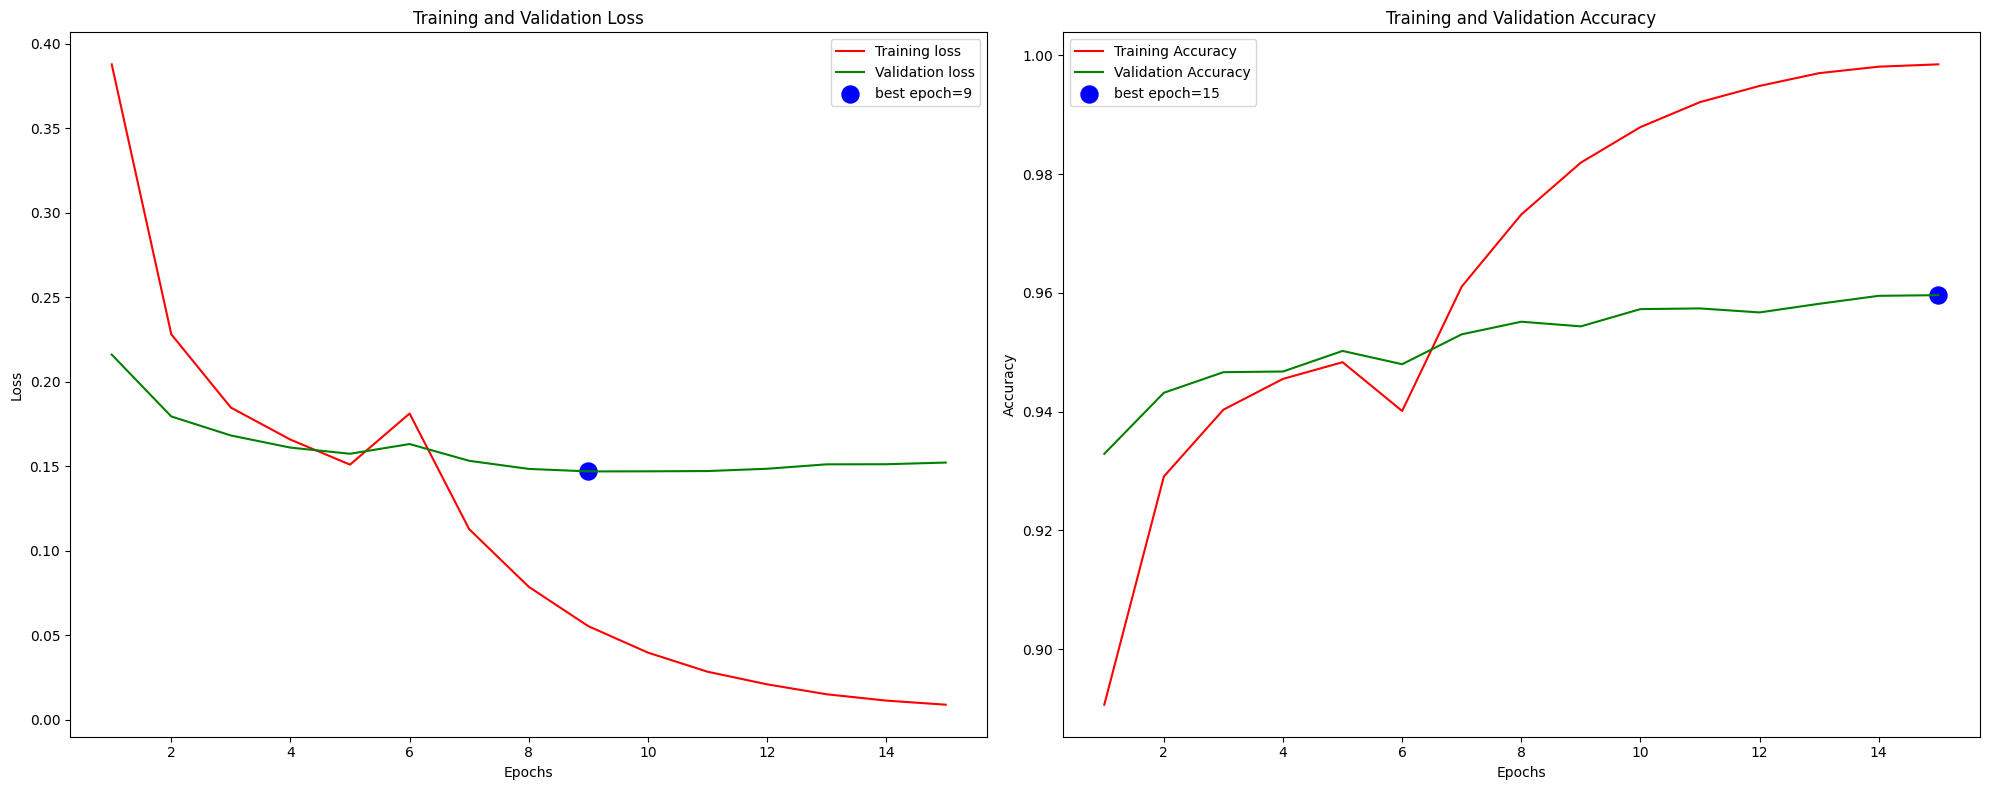

In [8]:
# =============================================================================
# Step 7: Plot Training History
# =============================================================================
tr_acc = history_head.history['accuracy'] + history_finetune.history['accuracy']
tr_loss = history_head.history['loss'] + history_finetune.history['loss']
val_acc = history_head.history['val_accuracy'] + history_finetune.history['val_accuracy']
val_loss = history_head.history['val_loss'] + history_finetune.history['val_loss']

Epochs = [i+1 for i in range(len(tr_acc))]
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss+1, val_lowest, s=150, c='blue', label=f'best epoch={index_loss+1}')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc+1, acc_highest, s=150, c='blue', label=f'best epoch={index_acc+1}')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:

# =============================================================================
# Step 8: Evaluate Model
# =============================================================================
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length+1) if ts_length%n==0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_generator, steps=test_steps, verbose=1)
valid_score = model.evaluate(valid_generator, steps=test_steps, verbose=1)
test_score = model.evaluate(test_generator, steps=test_steps, verbose=1)

print("Train Loss:", train_score[0], "| Train Accuracy:", train_score[1])
print("Valid Loss:", valid_score[0], "| Valid Accuracy:", valid_score[1])
print("Test Loss:", test_score[0], "| Test Accuracy:", test_score[1])


172/172 [==============================] - 53s 307ms/step - loss: 0.1400 - accuracy: 0.9610
Train Loss: 0.001238224096596241 | Train Accuracy: 1.0
Valid Loss: 0.15213686227798462 | Valid Accuracy: 0.9596332311630249
Test Loss: 0.14003494381904602 | Test Accuracy: 0.9609794020652771


70/70 [==============================] - 15s 199ms/step


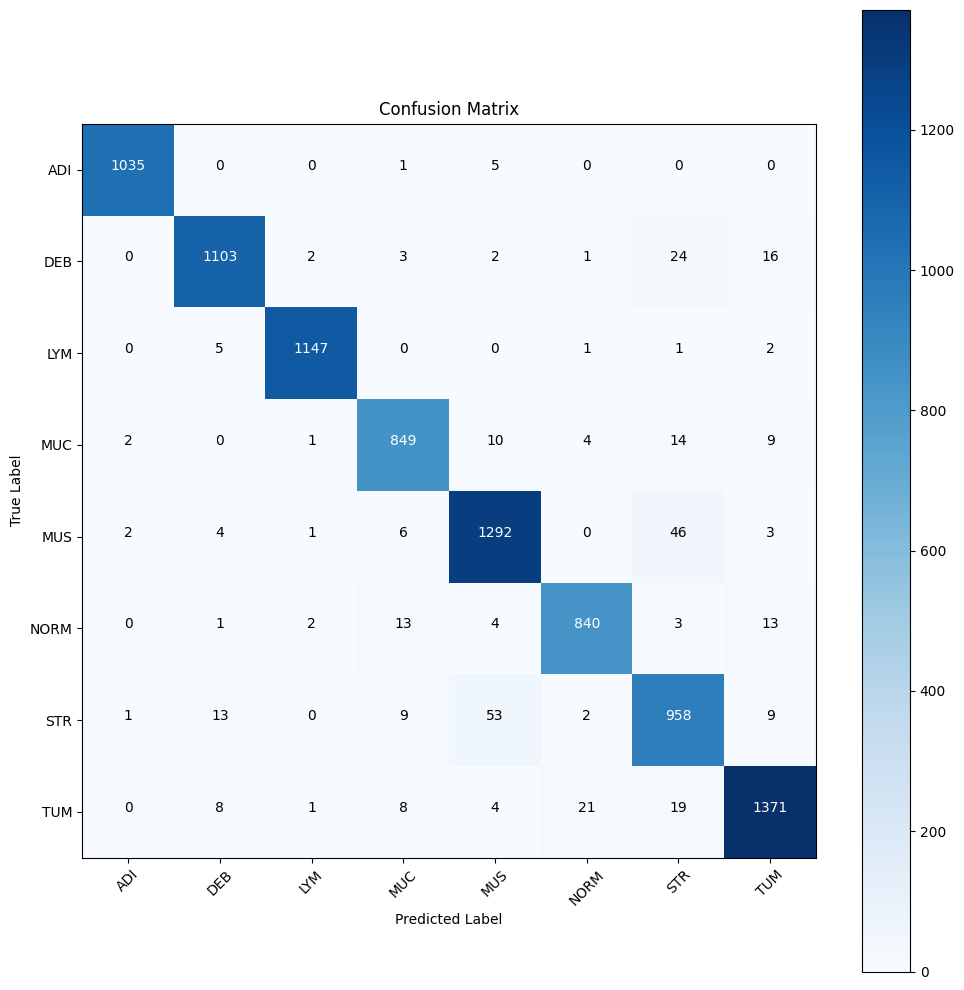

              precision    recall  f1-score   support

         ADI       1.00      0.99      0.99      1041
         DEB       0.97      0.96      0.97      1151
         LYM       0.99      0.99      0.99      1156
         MUC       0.96      0.96      0.96       889
         MUS       0.94      0.95      0.95      1354
        NORM       0.97      0.96      0.96       876
         STR       0.90      0.92      0.91      1045
         TUM       0.96      0.96      0.96      1432

    accuracy                           0.96      8944
   macro avg       0.96      0.96      0.96      8944
weighted avg       0.96      0.96      0.96      8944



In [10]:

# =============================================================================
# Step 9: Predictions and Metrics
# =============================================================================
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
classes = list(test_generator.class_indices.keys())

cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(10,10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
thresh = cm.max()/2.
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j,i,cm[i,j],horizontalalignment='center',color='white' if cm[i,j]>thresh else 'black')
plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(test_generator.classes, y_pred, target_names=classes))


In [11]:

# =============================================================================
# Step 10: Save the Model
# =============================================================================
model.save('ResNet50_Optimized_Model_Original.h5')